# Components of Dashboard and Expected layout


##### Components of the Dashboard
1. Select Region

2. Select Year

3. Divison to display

--Pie Chart to display Monthly Average Estimated Fire Area for the selected Regions in the selected Year

--Bar Chart to display Monthly Average Count of Pixels for Presumed Vegetation Fires for the selected Regions in the selected Year


### To do:
1. Import required libraries and read the dataset
2. Create an application layout
3. Add title to the dashboard using HTML H1 component
4. Add a radioitem using dcc.RaioItems and dropdown using dcc.dropdown
5. Add the pie chart and bar chart core graph components.
6. Run the app

# Explanation of the process: Do not try to run the following cell


In [ ]:
#*********IMPORT LIBRARIES*********
import pandas as pd
import dash
from dash import html, dcc
from dash.dependencies import Input, Output, State
import plotly.graph_objects as go
import plotly.express as px
from dash import no_update
import datetime as dt
# Initialize the Dash app
app = dash.Dash(__name__)
#Clear the layout and do not display exception till callback gets executed
app.config.suppress_callback_exceptions = True
# Read the wildfire data into pandas dataframe
df =  pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv')
#Extract year and month from the date column
df['Month'] = pd.to_datetime(df['Date']).dt.month_name() #used for the names of the months
df['Year'] = pd.to_datetime(df['Date']).dt.year
#Layout Section of Dash
#Task 1 Add the Title to the Dashboard
#**********  ************
#********** Add title to the dashboard--->html.H1('Australia Wildfire Dashboard', Use style parameter provided below to make the title 'center' aligned,
#with color code #503D36, and font-size as 26 ************
app.layout = html.Div(children=[html.H1('Australia Wildfire Dashboard', 
                                style={'textAlign': 'center', 'color': '#503D36',
                                'font-size': 26}),
# TASK 2: Add the radio items and a dropdown right below the first inner division
#********** The radio items work similar to the dropdown, you need to call dcc.RadioItems and pass the list of items. ************

     #outer division starts
     html.Div([
                   # First inner divsion for  adding dropdown helper text for Selected Drive wheels
                    html.Div([
                            html.H2('Select Region:', style={'margin-right': '2em'}),

                    #Radio items to select the region
                    #********** Make use of inline=True property to display the radio items in a horizontal line ************
                    #********** WE COULD USE THE FOLLOWING LINE ************
                    #********** You can extract the regions from the dataframe using df.Region.unique() or pass the list of all regions directly as ['NSW','QL','SA','TA','VI','WA','NT'].************                 
                    #dcc.RadioItems(['NSW','QL','SA','TA','VI','WA'], 'NSW', id='region',inline=True)]),
                    #********** OR you can use labels:value pair a well in raioditems as below ************
                    dcc.RadioItems([{"label":"New South Wales","value": "NSW"},
                                    {"label":"Northern Territory","value": "NT"},
                                    {"label":"Queensland","value": "QL"},
                                    {"label":"South Australia","value": "SA"},
                                    {"label":"Tasmania","value": "TA"},
                                    {"label":"Victoria","value": "VI"},
                                    {"label":"Western Australia","value": "WA"}],"NSW", id='region',inline=True)]),
                    #**********  ************
                    #Dropdown to select year
                    #********** The label as "Select Year" ************
                    #********** The default value when the dropdown is displayed is "2005" ************
                    #********** You can extract the year from the dataframe using df.Year.unique() ************
                    html.Div([
                            html.H2('Select Year:', style={'margin-right': '2em'}),
                        dcc.Dropdown(df.Year.unique(), value = 2005,id='year')
                    ]),
#TASK 3: Add two empty divisions for output inside the next inner division. 
         #Second Inner division for adding 2 inner divisions for 2 output graphs
         #********** Use 2 html.Div() tags ************
         #********** 'FLEX' makes it easy to align and distribute space among items in a container, even when their sizes are dynamic. ************
                    html.Div([
                
                        html.Div([ ], id='plot1'),
                        html.Div([ ], id='plot2')
                    ], style={'display': 'flex'}),

    ])
    #outer division ends

])
#layout ends
#TASK 4: Add the Ouput and input components inside the app.callback decorator.
#Place to add @app.callback Decorator
#**********The inputs and outputs of our application’s interface are described declaratively as the arguments of @app.callback decorator.
    #-In Dash, the inputs and outputs of our application are simply the properties of a particular component.
        #In this example, we have two inputs:-
            #- input for Region is the value property of the component that has the ID region
            #- input for Year is the value property of the component that has the ID year
        #Our layout has 2 outputs so we need to create 2 output components.
            #It is a list with 2 output parameters with component id and property. 
                #Here, the component property will be "children" as we have created empty division 
                #and passing in dcc.Graph (figure) after computation.
                #Component ids will be 'plot1' , 'plot2'.
@app.callback([Output(component_id='plot1', component_property='children'),
               Output(component_id='plot2', component_property='children')],
               [Input(component_id='region', component_property='value'),
                Input(component_id='year', component_property='value')])
#TASK 5: Add the callback function.
  #Place to define the callback function.
#*******Whenever an input property changes, the function that the callback decorator wraps will get called automatically.
    #In this case let us define a function reg_year_display() which will be wrapped by our decorator.
    #The function first filters our dataframe df by the selected value of the region from the radio items 
    #and year from the dropdown as follows:
    #region_data = df[df['Region'] == input_region]
    #y_r_data =region_data[region_data['Year']==input_year]


    #For pie chart on Monthly Average Estimated Fire Area:
        #Next we will group by the Month and calculate the mean Estimated_fire_area of the dataframe.
        #Use the px.pie() function to plot the pie chart
    #For bar chart on Monthly Average Count of Pixels for Presumed Vegetation Fires: 
        #Next we will group by the Month and calculate the mean Count of the dataframe.
        #Use the px.bar() function to plot the bar chart
def reg_year_display(input_region,input_year):  
    #data
   region_data = df[df['Region'] == input_region]
   y_r_data = region_data[region_data['Year']==input_year]
    #Plot one - Monthly Average Estimated Fire Area   
   est_data = y_r_data.groupby('Month')['Estimated_fire_area'].mean().reset_index()
   fig1 = px.pie(est_data, values='Estimated_fire_area', names='Month', title="{} : Monthly Average Estimated Fire Area in year {}".format(input_region,input_year))   
     #Plot two - Monthly Average Count of Pixels for Presumed Vegetation Fires
   veg_data = y_r_data.groupby('Month')['Count'].mean().reset_index()
   fig2 = px.bar(veg_data, x='Month', y='Count', title='{} : Average Count of Pixels for Presumed Vegetation Fires in year {}'.format(input_region,input_year))    
   #********** Finally we return the 2 figure objects fig1 and fig2 in dcc.Graph method. ************
   return [dcc.Graph(figure=fig1),
            dcc.Graph(figure=fig2) ]
#********** Run the App ************
if __name__ == '__main__':
    app.run_server()
    

# Result of the Code:

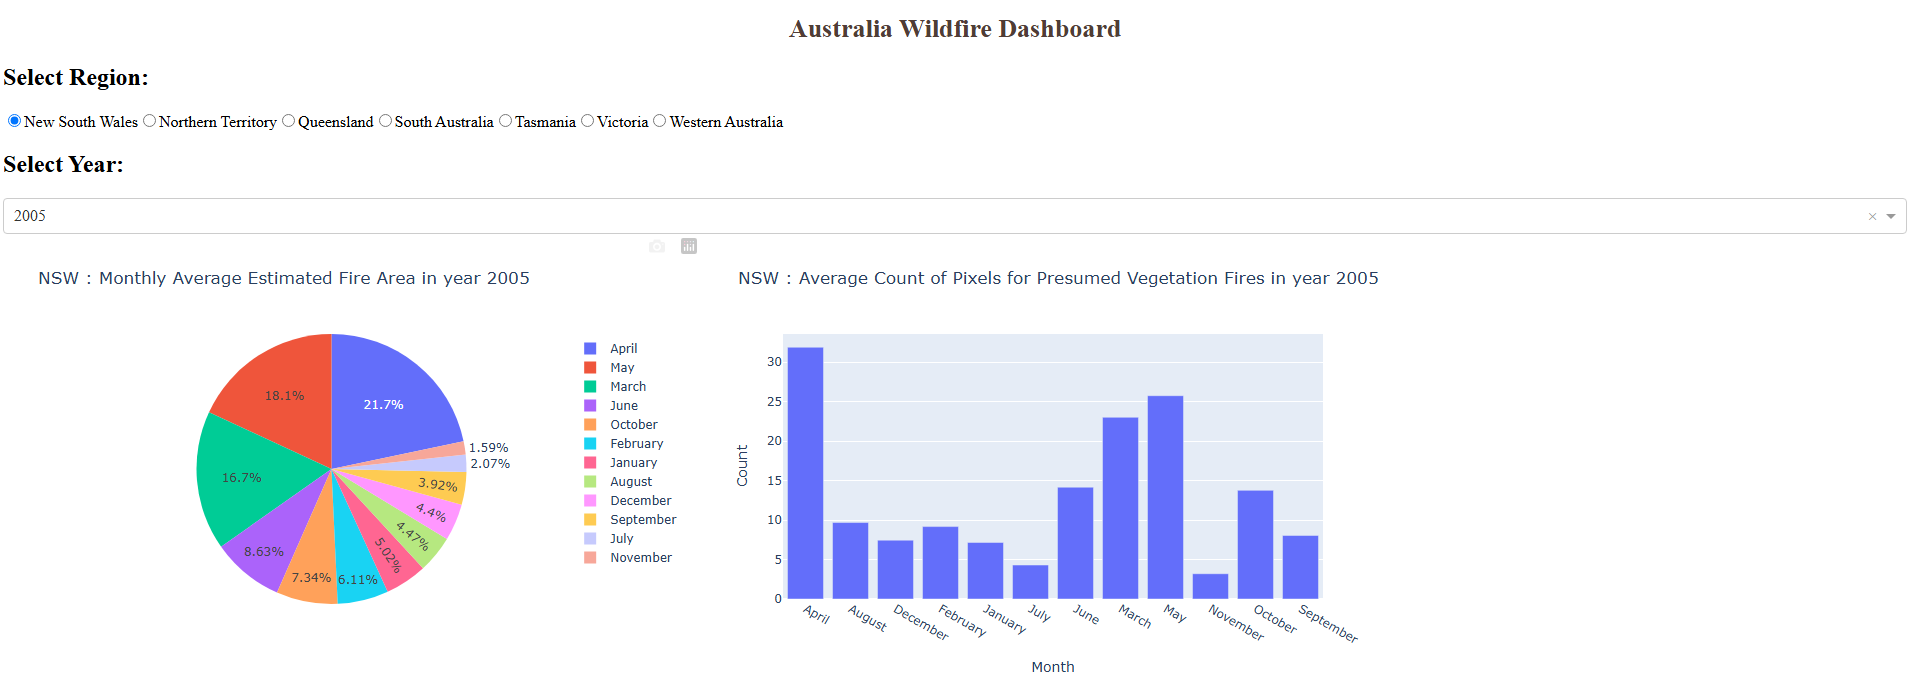

In [2]:
from IPython.display import Image

# Display an image from a file
Image(filename='Screenshot 2025-02-05 115326.png')